# utide-gpu on a real tide-gauge record

This notebook runs the whole workflow on the hourly sea-level record shipped
with the package (`can1998.dtf` — one year of observations, 1998): harmonic
analysis on the GPU, prediction versus the observations, and the empirical
tidal datums.

*(This is a single station, so the GPU is not faster here than the CPU — set
`gpu=False` to compare. The GPU win shows up when analysing a whole field of
series at once; see `gpu_batch_example.ipynb`.)*


In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import utide


## 1. Load and clean the record


In [2]:
raw = np.loadtxt("can1998.dtf")            # seconds year month day hour elev flag
t = raw[:, 0] / 86400.0                     # days since 1998-01-01
h = raw[:, 5].copy()
h[raw[:, 6] == 2] = np.nan                  # flag 2 == bad
h[np.abs(h - 9.990) < 1e-6] = np.nan        # missing sentinel
print(f"{np.isfinite(h).sum()} hourly samples, {np.isnan(h).sum()} gaps")


8750 hourly samples, 10 gaps


## 2. Harmonic analysis on the GPU

`gpu=True` runs the basis construction and solve on the GPU; results come back
on the host and match the CPU result to round-off.


In [3]:
coef = utide.solve(t, h, lat=-25, method="ols", conf_int="linear",
                   epoch="1998-01-01", gpu=True, verbose=False)
order = np.argsort(coef["A"])[::-1]
print(f"{len(coef['name'])} constituents\n")
print("constituent   amp (m)   phase (deg)")
for i in order[:8]:
    print(f"   {coef['name'][i]:5s}    {coef['A'][i]:7.3f}    {coef['g'][i]:7.1f}")


59 constituents

constituent   amp (m)   phase (deg)
   M2         0.372       97.7
   S2         0.243      103.4
   O1         0.109       85.6
   K2         0.077       91.7
   M3         0.068      232.5
   K1         0.065      148.5
   N2         0.063      162.0
   M4         0.057      213.1


## 3. Prediction vs observations

`reconstruct` predicts the tide from the fitted constituents.


RMS(observed - predicted) = 0.180 m,  79.2% of variance explained


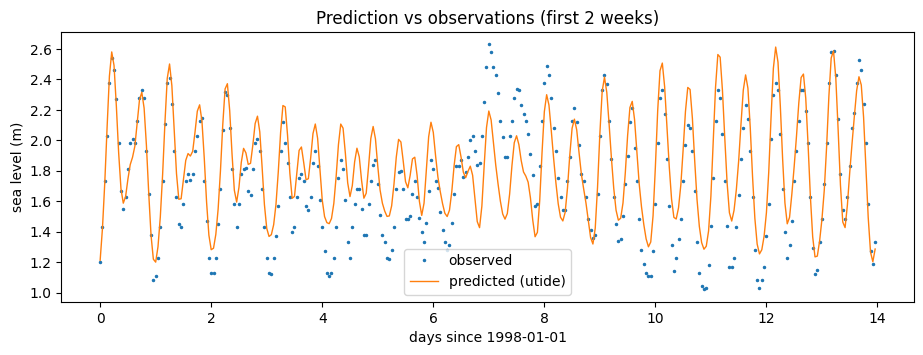

In [4]:
tide = utide.reconstruct(t, coef, epoch="1998-01-01", verbose=False)
resid = h - tide.h
rms = np.sqrt(np.nanmean(resid**2))
print(f"RMS(observed - predicted) = {rms:.3f} m,  "
      f"{100*(1-np.nanvar(resid)/np.nanvar(h)):.1f}% of variance explained")

w = slice(0, 24*14)
plt.figure(figsize=(11, 3.5))
plt.plot(t[w], h[w], ".", ms=3, label="observed")
plt.plot(t[w], tide.h[w], "-", lw=1, label="predicted (utide)")
plt.xlabel("days since 1998-01-01"); plt.ylabel("sea level (m)")
plt.title("Prediction vs observations (first 2 weeks)"); plt.legend(); plt.show()


## 4. Empirical tidal datums

`tidal_characteristics` extracts standard datums directly from the record by
detecting its high and low waters.


   MHW  =  2.164 m
   MLW  =  1.379 m
   MTL  =  1.772 m
   MTR  =  0.785 m
   ED   =  4.886 h
   FD   =  5.112 h


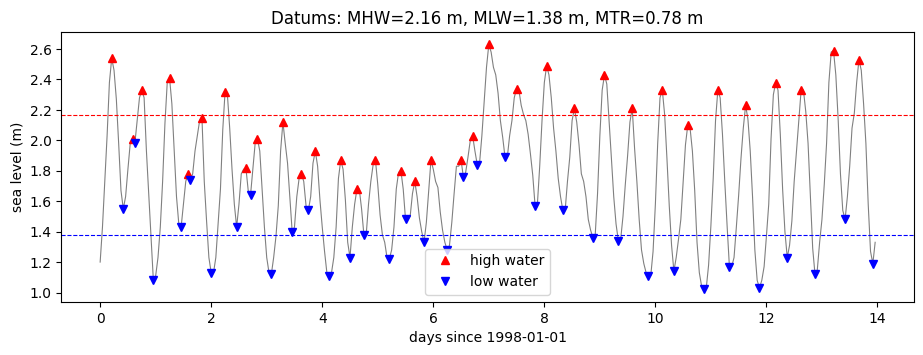

In [5]:
c = utide.tidal_characteristics(t, h)
for k in ["MHW", "MLW", "MTL", "MTR", "ED", "FD"]:
    print(f"   {k:4s} = {c[k]:6.3f} {'h' if k in ('ED','FD') else 'm'}")

w = slice(0, 24*14)
plt.figure(figsize=(11, 3.5))
plt.plot(t[w], h[w], "-", lw=0.8, color="0.5")
m = (c.hw_t >= t[w][0]) & (c.hw_t <= t[w][-1])
n = (c.lw_t >= t[w][0]) & (c.lw_t <= t[w][-1])
plt.plot(c.hw_t[m], c.hw_h[m], "r^", label="high water")
plt.plot(c.lw_t[n], c.lw_h[n], "bv", label="low water")
plt.axhline(c.MHW, color="r", ls="--", lw=0.8); plt.axhline(c.MLW, color="b", ls="--", lw=0.8)
plt.xlabel("days since 1998-01-01"); plt.ylabel("sea level (m)")
plt.title(f"Datums: MHW={c.MHW:.2f} m, MLW={c.MLW:.2f} m, MTR={c.MTR:.2f} m")
plt.legend(); plt.show()


To analyse a whole **field** of stations like this at once — extracting
constituents and datums everywhere in one call — pass an `(n_times, n_series)`
array to `utide.solve_many` and `utide.tidal_characteristics_many`.
